In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np
import arviz as az

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

# Model results (13 Aug 2026)
## Model fitting and pre-processing

Before running the analyses in this notebook, three steps (model fitting, simulation, and aggregation of model fitting results) need to be performed. Since fitting all models to all particpants can take a few days (depending on your computer), these steps have been performed and the results have been saved to the `results/` directory. 

If you want to replicate the full model fitting pipeline, you will need to run the following three steps. 

If you are interested in generating the main model figures starting from pre-processed model results, you can simply run this notebook and use the pre-generated model results / simulations.

### 1. Model fitting
Run `fit_multisensory.py` for each participant and each model ("optimal", "no_integration", "equal_integration", "vision_only") and model class ("BoundedActor", "BoundedActorPointMassDynamics"), e.g.
```bash
python fit_multisensory.py --participant 135033060 --model optimal --model_class BoundedActorPointMassDynamics
```

You can also use the script `fit_multisensory.sh` to run this for multiple participants, while running all models for one participant in pararallel. 

### 2. Model simulation
After fitting the models to the data from the baseline phase, we can simulate behaviour and save the simulated cross-correlgorams. Run `simulate_multisensory.py` for each participant and model class, e.g.
```bash
python simulate_multisensory.py --participant 135033060 --model_class BoundedActorPointMassDynamics
```

This will fill the directories `results/calibration` and `results/ccgs` with one file per model class and participants.

You can also use the script `simulate.sh` to run this for all participants.

### 3. Aggregate model fits
Finally, we need to save the model parameters and model comparison scores for each model and participant. To do this, run
```bash
python aggregate_multisensory_fits.py
```

This will create two files: `results/aggregated/loo_all_participants.csv` and `results/aggregated/summaries_all_participants.csv`

Once you have the files generated in steps 2 and 3, you can run this notebook.

## Model comparison across participants for pre-test phase 

Use Pareto-smoothed importance sampling approximation to leave-one-out cross-validation (PSIS-LOO), implemented in `arviz` (https://python.arviz.org/en/v0.22.0/api/generated/arviz.loo.html) and described by Vehtari et al. (2017, https://link.springer.com/article/10.1007/S11222-016-9696-4).

I have now stacked the data from all conditions together, so that we can get a single model comparison score for each participant using all of their baseline phase data.

In [53]:
loo_df = pd.read_csv('../results/aggregated/loo_all_participants.csv', index_col=0)
participants = loo_df["participant"].unique()

# rename integration type column for nicer visualization
integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}
loo_df["integration"] = loo_df["integration"].map(integration_name)

# rename dynamics model type column (for nicer visualization)
loo_df["dynamics"] = loo_df["model"].map(
    {"BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control"}
)
loo_df = loo_df[loo_df["dynamics"] == "Point mass"]  # only keep point mass dynamics for now

# create fixed order of models for plotting and set up color palette
model_order = ["Optimal integration", "Equal integration", "Prop. dominance", "Vis. dominance"]
palette = dict(zip(model_order, sns.color_palette("colorblind", 4)))

base_model = "Prop. dominance"  # set base model for computing elpd differences

# # compute difference with respect to the "optimal" model for each participant and dynamics model
base_elpd = loo_df.loc[loo_df["integration"] == base_model, ["participant", "dynamics", "elpd"]].rename(columns={"elpd": "base_elpd"})
loo_df = loo_df.merge(base_elpd, on=["participant", "dynamics"], how="left")
loo_df["elpd_diff"] = loo_df["elpd"] - loo_df["base_elpd"]



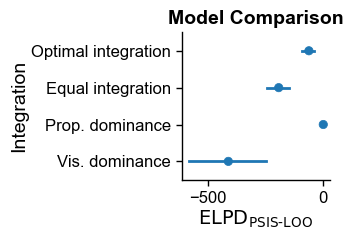

In [54]:
g = (so.Plot(loo_df, y="integration", x="elpd_diff")
      .add(so.Dot(), so.Agg())
      # .add(so.Dot(pointsize=2), so.Jitter())
      .add(so.Range(), so.Est(func="mean", errorbar="ci"))
    #   .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .layout(size=(3.5,2.5))
      .scale(y=so.Nominal(order=model_order),
             x=so.Continuous().tick(upto=2))
      # .facet(row="participant")
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Integration", color="Dynamics", title="Model Comparison")
)
g.show()

In [55]:
agg_df = loo_df.groupby(["integration", "dynamics"]).agg(
    elpd_diff_mean=("elpd_diff", "mean"),
    elpd_diff_se=("elpd_diff", "sem"),
)

agg_df

,,elpd_diff_mean,elpd_diff_se
integration,dynamics,,
Equal integration,Point mass,-192.974276,25.690864
Optimal integration,Point mass,-62.186111,13.128226
Prop. dominance,Point mass,0.000000,0.000000
Vis. dominance,Point mass,-411.202880,88.569297


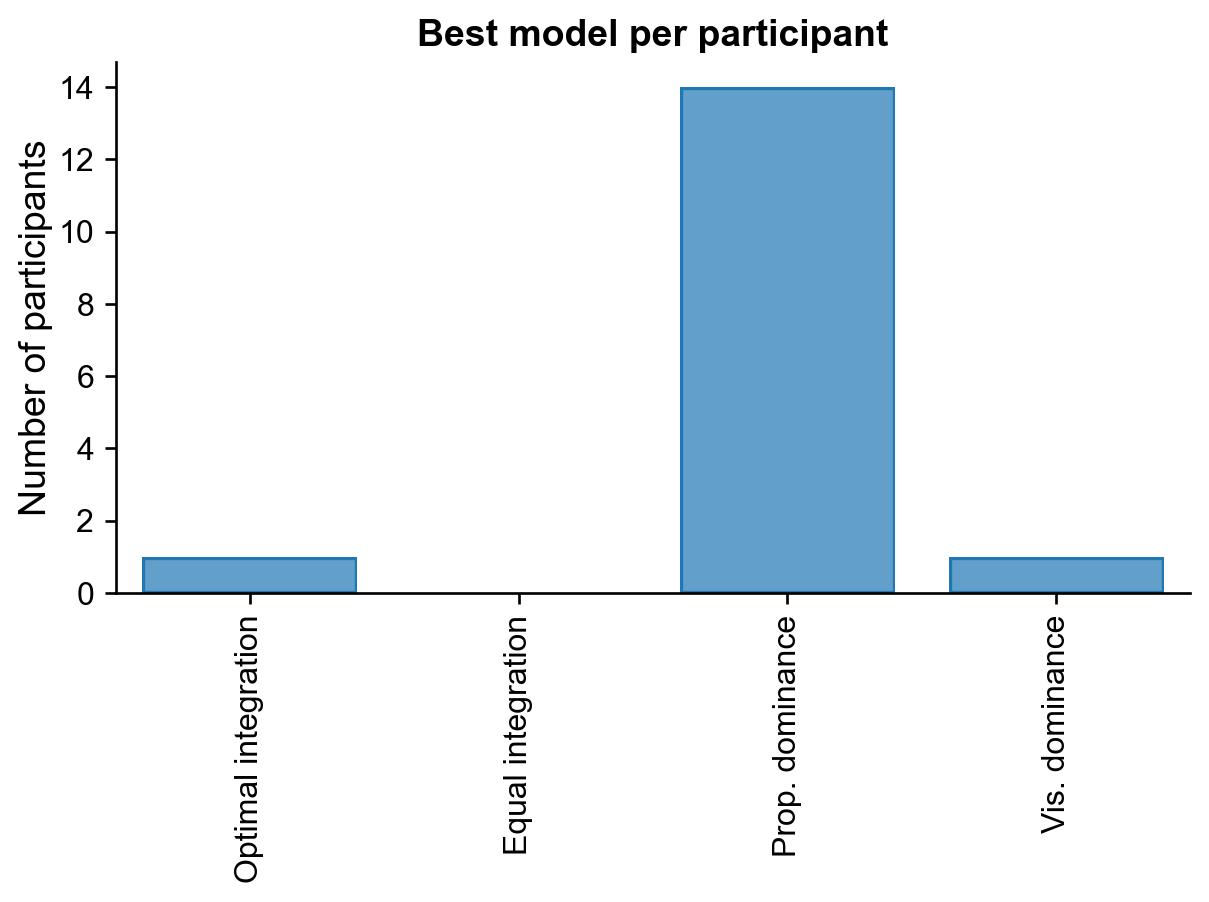

In [56]:
# get the best-fitting model per participant
best_per_participant = (
    loo_df.loc[loo_df.groupby("participant")["elpd"].idxmax(), ["integration", "dynamics", "participant"]]
)

win_counts = (
    best_per_participant["integration"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["integration", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

g = (
    so.Plot(win_counts, x="integration", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal())
    .label(x="", y="Number of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g

## Parameter estimates (uncertainty, cost, variability) 

In [9]:
# read data frame containing parameter estimate summaries
summary_df = pd.read_csv("../results/aggregated/summaries_all_participants.csv", index_col = 0)

# rename columns containg model type for integration and dynamics
summary_df["integration"] = summary_df["integration"].map(integration_name)
summary_df["dynamics"] = summary_df["model"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })


In [10]:
param_names = {"sigma_prop": "Hand", "sigma_vis[0]": "Cursor", "sigma_vis[1]": "Cloud",
               "action_variability": "Action variability", "action_cost": "Action cost", 
               "vis_prop_diff[0]": "Cursor - hand", "vis_prop_diff[1]": "Cloud - hand"}

# get the parts of df that correspond to the best model for each participant
best_model_params = summary_df.merge(best_per_participant, on=["participant", "integration", "dynamics"])
best_model_params["parameter"] = best_model_params["parameter"].map(lambda x: param_names.get(x, x))
summary_df["parameter"] = summary_df["parameter"].map(lambda x: param_names.get(x, x))


### Perceptual uncertainty 

In [12]:
best_model_params[best_model_params["parameter"].isin(["Cursor - hand", "Cloud - hand"])].groupby(["parameter"]).apply(lambda x: (x["hdi_3%"] > 0.).sum())

/tmp/ipykernel_1456055/435023660.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_model_params[best_model_params["parameter"].isin(["Cursor - hand", "Cloud - hand"])].groupby(["parameter"]).apply(lambda x: (x["hdi_3%"] > 0.).sum())


parameter
Cloud - hand     16
Cursor - hand    14
dtype: int64

### Action cost and variability

Note: the action variability parameter can be interpreted in the same units as the data, whereas the action cost parameter is unitless, so the y axis does not have the same interpretation.

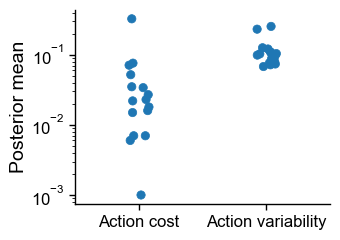

In [14]:
g = (
    so.Plot(
        best_model_params[
            (
                best_model_params["parameter"].isin(
                    ["Action cost", "Action variability"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="model_short",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 1.0))
    .label(x="", y="Posterior mean")
    .scale(color=so.Nominal(), y="log")
    # .facet(col="parameter")
    .layout(size=(3.5, 2.5))
)
g.show()

## Posterior predictive for a representative participant

Plotting raw trajectories for a single participant 

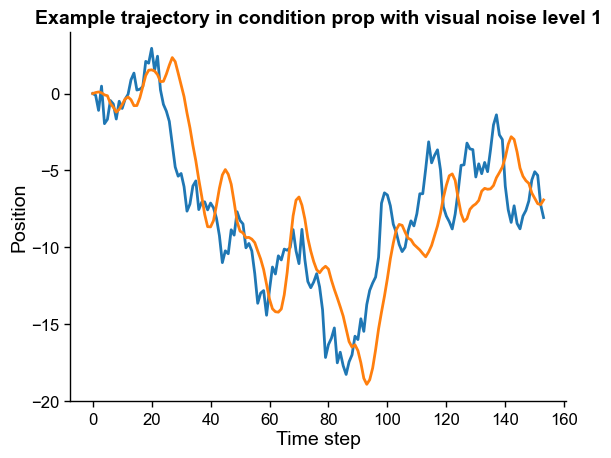

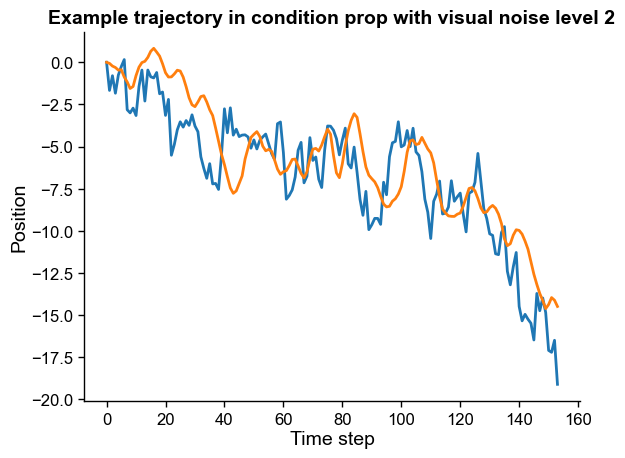

In [15]:
example_participant = 765738475
example_participant_model = az.from_netcdf(f"../results/multisensory_fits/multisensory-mcmc-{example_participant}_1_2_3_2500_2500_4_no_integration_BoundedActorPointMassDynamics_['prop', 'vis', 'multi'].nc")


for vis_noise in [1, 2]:
    condition = "prop"
    sim_data = example_participant_model.posterior_predictive[f"x_{condition}_{vis_noise}"]

    # just pick one 'random' sample
    chain_idx = 0
    sample_idx = 100
    plt.figure()
    plt.plot(sim_data[chain_idx, sample_idx, :, 0])
    plt.plot(sim_data[chain_idx, sample_idx, :, 1])
    plt.xlabel("Time step")
    plt.ylabel("Position")
    plt.title(f"Example trajectory in condition {condition} with visual noise level {vis_noise}")

## Load and plot simulated CCGs

We load the posterior-predictive checks for the cross-correlograms for all participants

In [16]:
model_classes = ["BoundedActorPointMassDynamics"]
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_3_2500_2500_4_{model_class}_['prop', 'vis', 'multi'].csv") for p in participants for model_class in model_classes]).reset_index(drop=True)

ccgs["Condition"] = ccgs["condition"].map({"vis": "Vision", "prop": "Proprioception", "multi": "Multisensory"})
ccgs["Visual target"] = ccgs["vis_noise"].map({1: "Cursor", 2: "Cloud"})
ccgs["integration"] = ccgs["model"].map(integration_name)
ccgs["dynamics"] = ccgs["model_class"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })

Plotting model Point mass


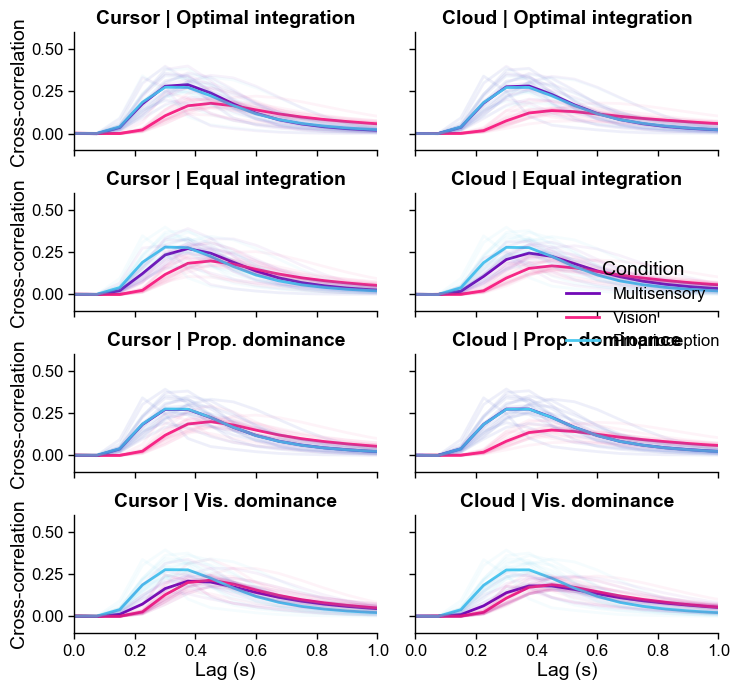

In [17]:

palette = {'Vision': "#F72585", 'Proprioception':  "#4CC9F0", 'Multisensory': "#7209B7"}
for model_class in ccgs["dynamics"].unique():
    print(f"Plotting model {model_class}")
    g = (so.Plot(ccgs[ccgs["dynamics"] == model_class], x="lag", y="correlation", color="Condition")
        .add(so.Line(), so.Agg())
        .add(so.Line(alpha=0.05), so.Agg(), group="participant")
        # .add(so.Band(), so.Est())
        .facet(col="Visual target",  
        row="integration", order={"row": model_order}
            )
        .label(x="Lag (s)", y="Cross-correlation")
        .limit(x=(-0.0, 1.0), y=(-0.1, 0.6))
        # .scale(color=so.Nominal({"vis": sns.color_palette("colorblind")[3], "prop": sns.color_palette("colorblind")[0], "multi": sns.color_palette("colorblind")[4]}))
        .scale(color=so.Nominal(palette))
        .layout(size=(7.5, 7.0))
    )
    g.show()

## CCG parameters (peak)

In [18]:
def fit_gaussian_to_ccg(lags, correlations):
    """
    Fit a Gaussian to the cross-correlation function to get a more accurate estimate of the lag at which the peak occurs.
    """
    from scipy.optimize import curve_fit

    def gaussian(x, a, x0, sigma):
        return a * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

    # initial guess for the parameters
    initial_guess = [correlations.max(), lags.iloc[np.argmax(correlations)], 0.1]

    try:
        popt, _ = curve_fit(gaussian, lags, correlations, p0=initial_guess)
        return popt[1]  # return the mean (x0) of the fitted Gaussian
    except RuntimeError:
        # if the fit fails, return the lag at which the maximum correlation occurs
        return lags.iloc[np.argmax(correlations)]

ccg_params = ccgs.groupby(["participant", "integration", "dynamics", "Condition", "Visual target"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        # 'lag': g.loc[g['correlation'].idxmax(), 'lag']
        # fit a Gaussian to the cross-correlation function to get a more accurate estimate of the lag at which the peak occurs
        'lag': fit_gaussian_to_ccg(g['lag'], g['correlation'])
    }),
    include_groups=False
).reset_index()

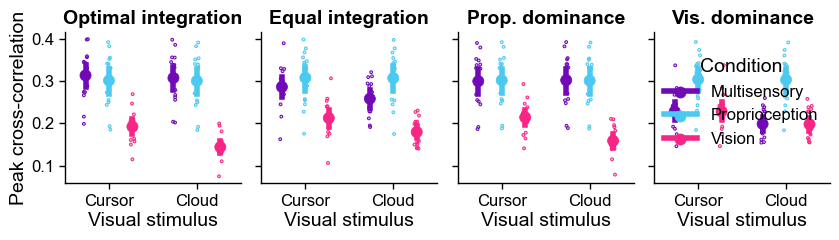

In [19]:
g = (so.Plot(ccg_params[ccg_params["dynamics"] == "Point mass"], x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="integration", order=model_order)
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    .layout(size=(8.5, 2.5))
    # .share(y=False)
)

g.save("../figures/model_ccg_peaks.svg")
g.show()

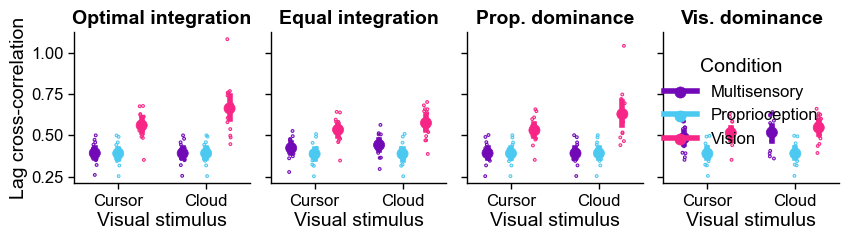

In [ ]:
g = (so.Plot(ccg_params[ccg_params["dynamics"] == "Point mass"], x="Visual target", y="lag", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="integration", order=model_order)
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Cross-correlation lag (s)")
    .layout(size=(8.5, 2.5))
    # .share(y=False)
)

g.save("../figures/model_ccg_lags.svg")
g.show()

## Compare data and simulations in offset phase


First, we load the model simulations in the offset phase for all participants 

In [21]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_3_2500_2500_4_{model_class}_['prop', 'vis', 'multi'].csv") for p in participants for model_class in model_classes]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]


In [22]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

df_sim["integration"] = df_sim["model"].map(integration_name)
df_sim["dynamics"] = df_sim["model_class"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

In [23]:
mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "integration", "dynamics", "Visual target", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .median()
    .reset_index()
)


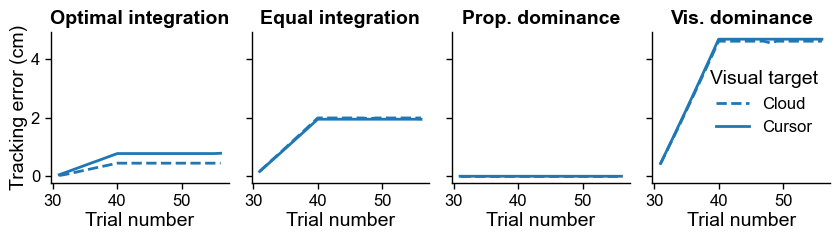

In [24]:
g = (
    so.Plot(
        mean_df[mean_df["dynamics"] == "Point mass"],
        x="trial_number",
        y="tracking_error",
        linestyle="Visual target",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Cursor": "-", "Cloud": "--"}))
    .facet(col="integration", order={"col": model_order})
    .layout(size=(8.5, 2.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.save("../figures/predictions_offset.svg")
g.show()

## Likelihood in offset phase


In [57]:
# aggregate log likelihood csv files
likelihood_df = pd.concat(
    [
        pd.read_csv(
            f"../results/calibration/multisensory-simulations-calibration-likelihoods-{participant}_1_2_3_2500_2500_4_{model_class}_['prop', 'vis', 'multi'].csv"
        )
        for participant in participants
        for model_class in ["BoundedActorPointMassDynamics"]
    ]
)


# aggregate log likelihoods across trials and visual noise levels for each participant and model
likelihood_df = likelihood_df.groupby(["model", "model_class", "participant"]).agg({"log_likelihood": "sum"}).reset_index()

# rename integration type column for nicer visualization
integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}
likelihood_df["integration"] = likelihood_df["model"].map(integration_name)

# rename dynamics model type column (for nicer visualization)
likelihood_df["dynamics"] = likelihood_df["model_class"].map(
    {"BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control"}
)
likelihood_df = likelihood_df[likelihood_df["dynamics"] == "Point mass"]  # only keep point mass dynamics model

# get each participant's difference in log likelihood with respect to the "Prop. dominance" model
base_likelihood = likelihood_df.loc[likelihood_df["integration"] == base_model, ["participant", "dynamics", "log_likelihood"]].rename(columns={"log_likelihood": "base_log_likelihood"})
likelihood_df = likelihood_df.merge(base_likelihood, on=["participant", "dynamics"], how="left")
likelihood_df["log_likelihood_diff"] = likelihood_df["log_likelihood"] - likelihood_df["base_log_likelihood"]
likelihood_df

,model,model_class,participant,log_likelihood,integration,dynamics,base_log_likelihood,log_likelihood_diff
0,equal_integration,BoundedActorPointMassDynamics,135033060,-24443.609589,Equal integration,Point mass,-20263.397491,-4180.212097
1,equal_integration,BoundedActorPointMassDynamics,177196795,-24846.090057,Equal integration,Point mass,-14413.979691,-10432.110367
2,equal_integration,BoundedActorPointMassDynamics,182095555,-34801.117126,Equal integration,Point mass,-23120.852539,-11680.264587
3,equal_integration,BoundedActorPointMassDynamics,212056115,-43118.535431,Equal integration,Point mass,-18433.483398,-24685.052032
4,equal_integration,BoundedActorPointMassDynamics,524048600,-35557.167389,Equal integration,Point mass,-21144.207062,-14412.960327
...,...,...,...,...,...,...,...,...
59,vision_only,BoundedActorPointMassDynamics,802096684,-43823.255920,Vis. dominance,Point mass,-21024.926346,-22798.329575
60,vision_only,BoundedActorPointMassDynamics,879521247,-40233.240234,Vis. dominance,Point mass,-18367.473495,-21865.766739
61,vision_only,BoundedActorPointMassDynamics,891444214,-43797.329041,Vis. dominance,Point mass,-29333.318939,-14464.010101
62,vision_only,BoundedActorPointMassDynamics,910949717,-44840.317078,Vis. dominance,Point mass,-24221.192993,-20619.124084


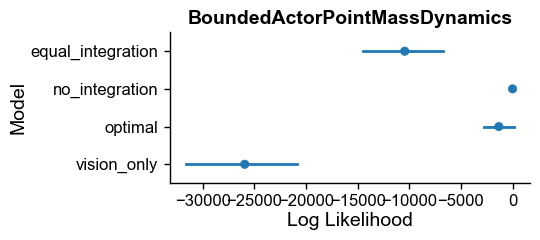

In [58]:
g = (so.Plot(likelihood_df, y="model", x="log_likelihood_diff")
    .add(so.Dot(), so.Agg("mean"))
    .add(so.Range(), so.Est(errorbar="ci"))
    # .add(so.Lines(), so.Agg("sum"))
    # .add(so.Lines(), so.Agg("sum"))
    # .facet(col="participant")
    .scale(color=so.Nominal())
    .facet(col="model_class")
    .layout(size=(5.5, 2.5))
            .label(y="Model", x="Log Likelihood")
)
g.show()

In [60]:
agg_likelihood_df = likelihood_df.groupby(["integration", "dynamics"]).agg(
    elpd_diff_mean=("log_likelihood_diff", "mean"),
    elpd_diff_se=("log_likelihood_diff", "sem"),
)

agg_likelihood_df

,,elpd_diff_mean,elpd_diff_se
integration,dynamics,,
Equal integration,Point mass,-10437.622131,1999.864855
Optimal integration,Point mass,-1322.658546,755.851306
Prop. dominance,Point mass,0.000000,0.000000
Vis. dominance,Point mass,-25921.132998,2822.350807


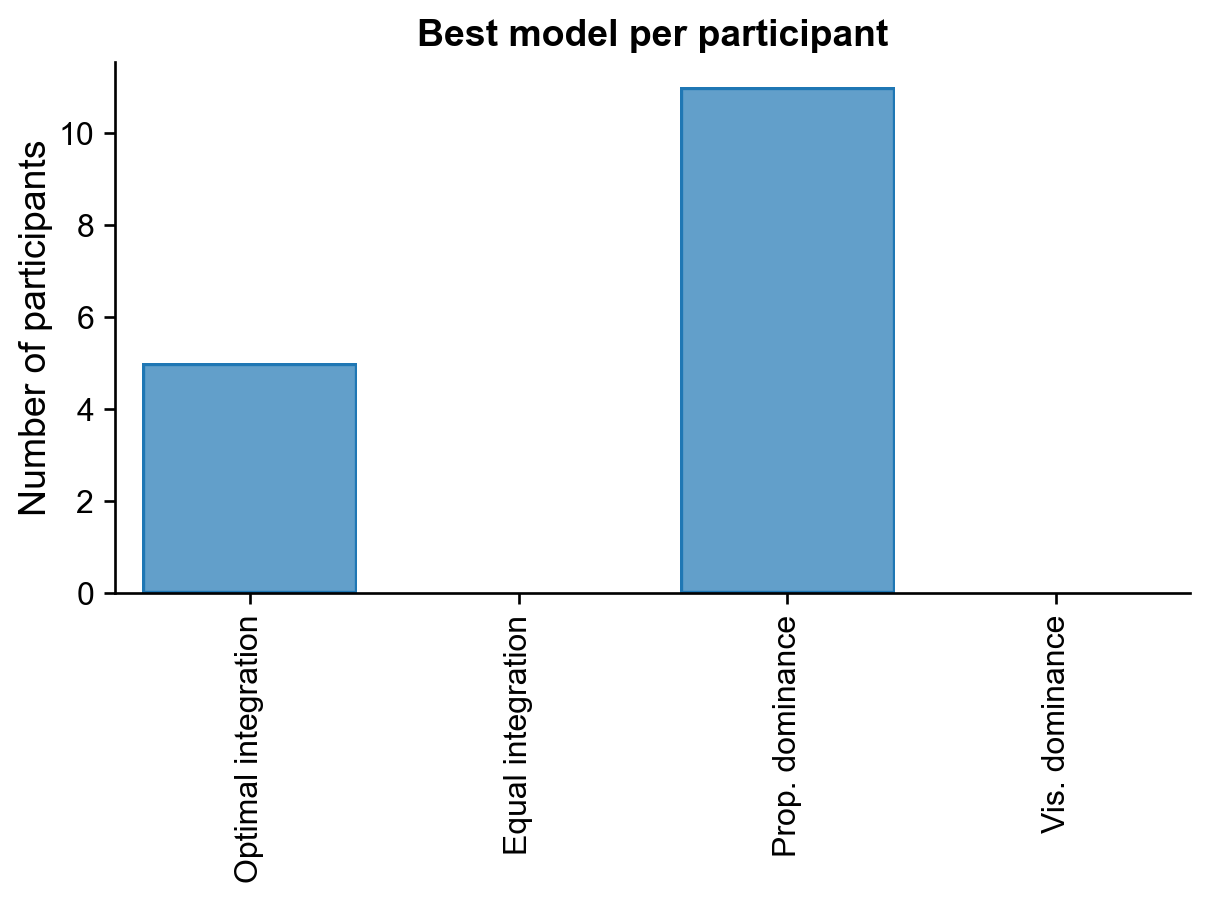

In [61]:
# get the best-fitting model per participant
best_per_participant_offset = (
    likelihood_df.loc[likelihood_df.groupby("participant")["log_likelihood"].idxmax(), ["integration", "dynamics", "participant"]]
)

win_counts_offset = (
    best_per_participant_offset["integration"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts_offset.columns = ["integration", "wins"]
win_counts_offset["n_participants"] = win_counts_offset["wins"] 

g = (
    so.Plot(win_counts_offset, x="integration", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal())
    .label(x="", y="Number of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g